# Import libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Read the dataset

In [3]:
df = pd.read_csv("Loan_default_cleaned.csv")

print(df.head())
print(df.shape)
print(df.columns)

       loanid       age    income  ...  loanpurpose  hascosigner  default
0  I38PQUQS96  0.833990  0.089693  ...            4            1        0
1  HPSK72WA7R  1.701221 -0.823021  ...            4            1        0
2  C1OZ6DPJ8Y  0.166888  0.043854  ...            0            0        1
3  V2KKSFM3UN -0.767053 -1.303452  ...            1            0        0
4  EY08JDHTZP  1.100830 -1.592855  ...            0            0        0
[5 rows x 18 columns]
(255347, 18)
Index(['loanid', 'age', 'income', 'loanamount', 'creditscore',
       'monthsemployed', 'numcreditlines', 'interestrate', 'loanterm',
       'dtiratio', 'education', 'employmenttype', 'maritalstatus',
       'hasmortgage', 'hasdependents', 'loanpurpose', 'hascosigner',
       'default'],
      dtype='str')


# Separate Input and Output

In [4]:
x = df.drop(columns = ["loanid", "default"])
y = df["default"]

In [5]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (255347, 16)
y shape: (255347,)


# Split the dataset

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

# Create the Random Forest model

In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the model

In [8]:
rf.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

# Make predictions

In [9]:
y_pred = rf.predict(x_test)

In [10]:
y_prob_rf = rf.predict_proba(x_test)[:, 1]

# Check Training vs Testing Score

In [11]:
train_score_rf = rf.score(x_train, y_train)
test_score_rf = rf.score(x_test, y_test)

print("Training Score:", train_score_rf)
print("Testing Score:", test_score_rf)
print("Difference:", train_score_rf - test_score_rf)

Training Score: 0.8875154814296274
Testing Score: 0.8861170941844527
Difference: 0.0013983872451747148


# Accuracy

In [12]:
accuracy_rf = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8861170941844527


# Confusion Matrix

In [13]:
cm_rf = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[45117    53]
 [ 5763   137]]


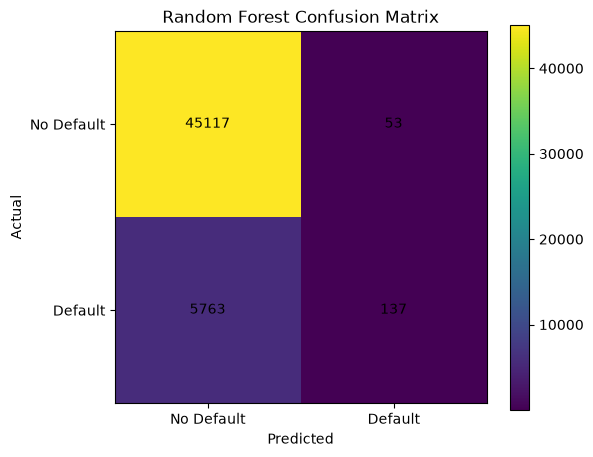

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cm_rf)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# Classification Report

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support
           0       0.89      1.00      0.94     45170
           1       0.72      0.02      0.04      5900
    accuracy                           0.89     51070
   macro avg       0.80      0.51      0.49     51070
weighted avg       0.87      0.89      0.84     51070


# ROC-AUC

In [17]:
from sklearn.metrics import roc_auc_score

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.7513721421522459


# STEP 1: Model Evaluation (Class 1 - Default Metrics)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred)
recall_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)


Accuracy : 0.8861170941844527
Precision: 0.7210526315789474
Recall   : 0.02322033898305085
F1-score : 0.04499178981937603


# STEP 3: 5-Fold Cross-Validation


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Random Forest CV Scores:", cv_scores_rf)
print("Mean CV Score:", cv_scores_rf.mean())
print("Standard Deviation:", cv_scores_rf.std())


Random Forest CV Scores: [0.88545134 0.88532896 0.88520377 0.88517929 0.88468976]
Mean CV Score: 0.8851706240102727
Standard Deviation: 0.00025933759010038804
